<a href="https://colab.research.google.com/github/teejiayi99-droid/KQC-7016-Assignment-2/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# Assignment 2: AI for Medicine
# Topic: Heart Disease Risk Prediction and Patient Profiling
# Dataset: heart_disease_uci.csv
# Methods: Classification + Clustering

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

In [37]:
# 1. Mount Google Drive and Load Dataset

drive.mount('/content/drive')

CSV_FILE = "/content/drive/MyDrive/Colab Notebooks/heart_disease_uci.csv"

df = pd.read_csv(CSV_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.
Shape: (920, 16)

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Column names:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [38]:
# 2. Initial Data Understanding

print("\nDataset information:")
df.info()

print("\nMissing values before cleaning:")
display(df.isnull().sum())

print("\nDuplicated rows before cleaning:")
print(df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe())

print("\nOriginal target variable distribution: num")
display(df["num"].value_counts().sort_index())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Missing values before cleaning:


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55



Duplicated rows before cleaning:
0

Summary statistics:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000



Original target variable distribution: num


,count
num,
0,411
1,265
2,109
3,107
4,28


In [39]:
# 3. Data Cleaning

df_clean = df.copy()

# Remove duplicated rows
df_clean = df_clean.drop_duplicates()

print("Duplicated rows after cleaning:", df_clean.duplicated().sum())

# Replace impossible zero values with NaN
# These clinical variables should not realistically be zero.
zero_invalid_cols = ["trestbps", "chol", "thalch"]

for col in zero_invalid_cols:
    if col in df_clean.columns:
        zero_count = (df_clean[col] == 0).sum()
        print(f"{col}: {zero_count} zero values found")
        df_clean[col] = df_clean[col].replace(0, np.nan)

# Create binary target variable
# num = 0 means no heart disease
# num > 0 means heart disease present
df_clean["HeartDisease"] = np.where(df_clean["num"] == 0, 0, 1)

print("\nBinary target distribution:")
display(df_clean["HeartDisease"].value_counts())

print("\nBinary target percentage:")
display(df_clean["HeartDisease"].value_counts(normalize=True) * 100)

print("\nMissing values after cleaning:")
display(df_clean.isnull().sum())

print("\nCleaned dataset shape:", df_clean.shape)

Duplicated rows after cleaning: 0
trestbps: 1 zero values found
chol: 172 zero values found
thalch: 0 zero values found

Binary target distribution:


,count
HeartDisease,
1,509
0,411



Binary target percentage:


,proportion
HeartDisease,
1,55.326087
0,44.673913



Missing values after cleaning:


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,60
chol,202
fbs,90
restecg,2
thalch,55



Cleaned dataset shape: (920, 17)


In [40]:
# 4. Outlier Detection using IQR

outlier_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

outlier_summary = []

for col in outlier_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df_clean[
            (df_clean[col] < lower_bound) |
            (df_clean[col] > upper_bound)
        ]

        outlier_summary.append({
            "Variable": col,
            "Lower Bound": round(lower_bound, 2),
            "Upper Bound": round(upper_bound, 2),
            "Number of Outliers": len(outliers)
        })

outlier_summary_df = pd.DataFrame(outlier_summary)

print("Outlier Summary using IQR Method:")
display(outlier_summary_df)

Outlier Summary using IQR Method:


,Variable,Lower Bound,Upper Bound,Number of Outliers
0,age,27.50,79.50,0
1,trestbps,90.00,170.00,27
2,chol,109.88,376.88,23
3,thalch,64.50,212.50,2
4,oldpeak,-2.25,3.75,16


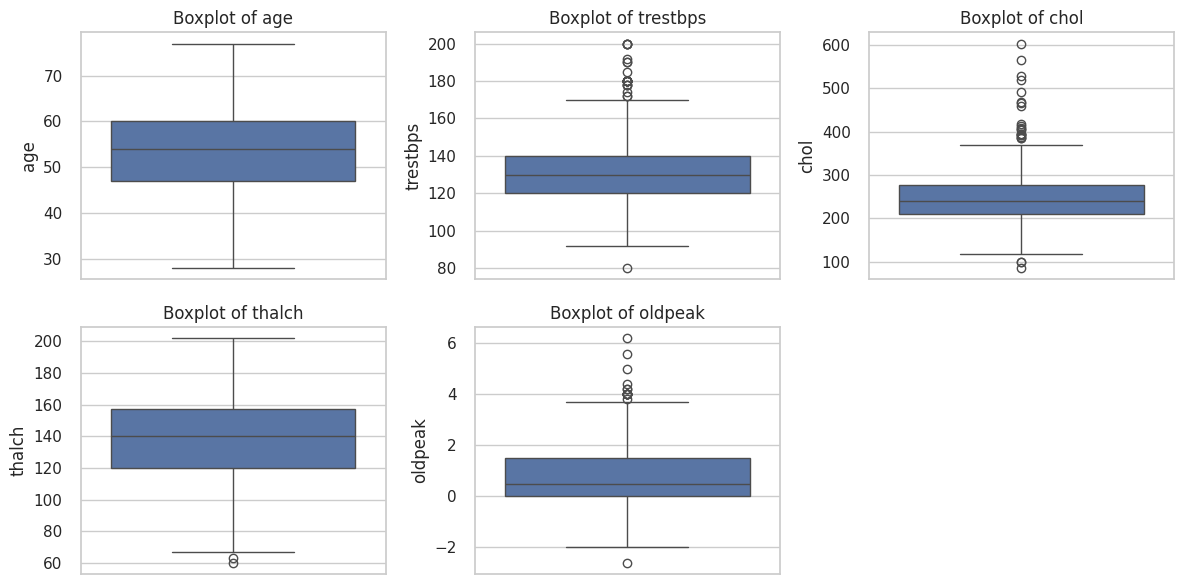

In [41]:
# 5. Outlier Visualization

plt.figure(figsize=(12, 6))

plot_index = 1

for col in outlier_cols:
    if col in df_clean.columns:
        plt.subplot(2, 3, plot_index)
        sns.boxplot(y=df_clean[col])
        plt.title(f"Boxplot of {col}")
        plot_index += 1

plt.tight_layout()
plt.show()

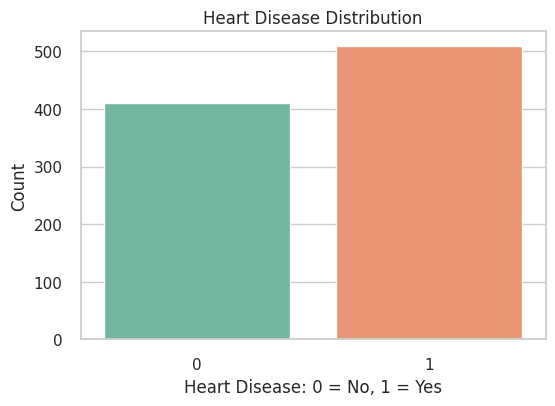

In [42]:
# 6. Basic EDA: Target Distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="HeartDisease",
    hue="HeartDisease",
    palette="Set2",
    legend=False
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

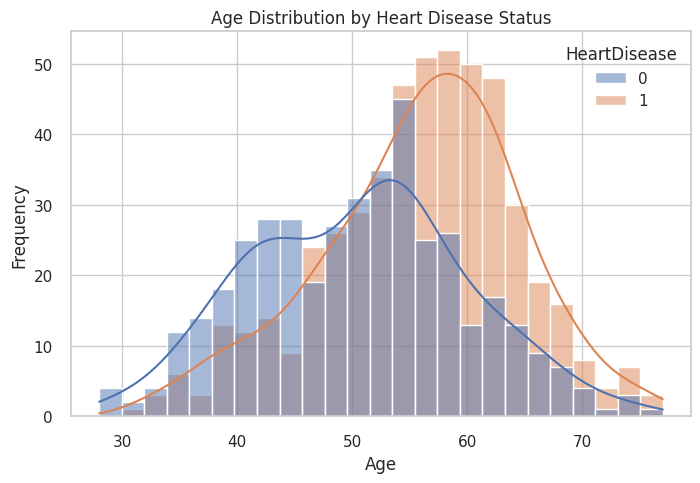

In [43]:
# 7. EDA: Age Distribution by Heart Disease Status

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    hue="HeartDisease",
    kde=True,
    bins=25
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

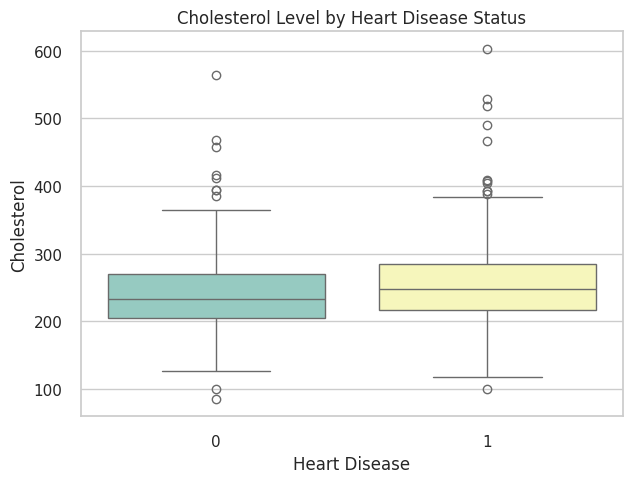

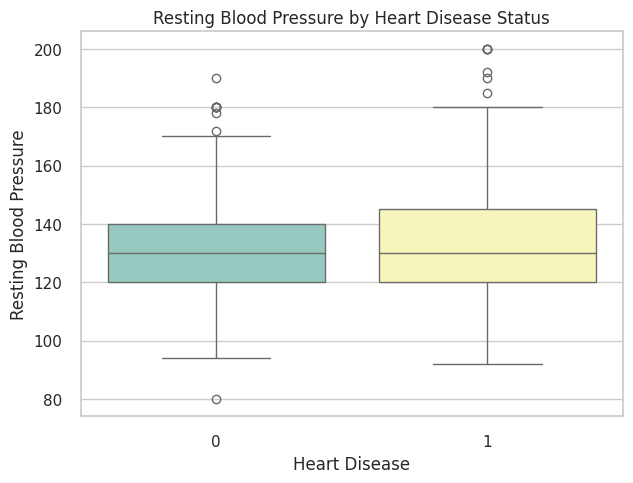

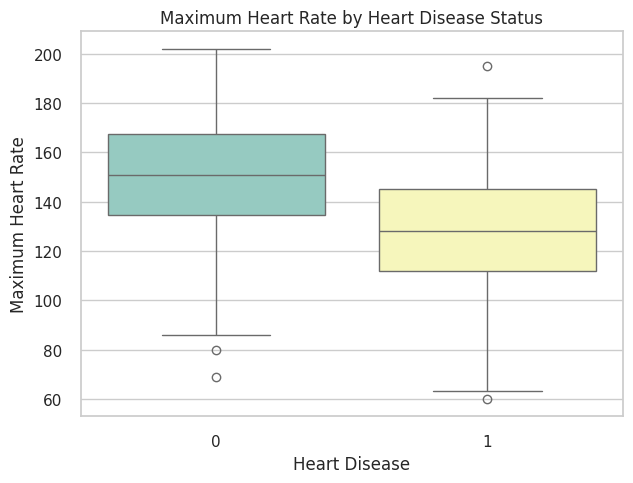

In [44]:
# 8. EDA: Clinical Variables by Heart Disease Status

# Cholesterol by heart disease
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_clean,
    x="HeartDisease",
    y="chol",
    hue="HeartDisease",
    palette="Set3",
    legend=False
)
plt.title("Cholesterol Level by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")
plt.show()

# Resting blood pressure by heart disease
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_clean,
    x="HeartDisease",
    y="trestbps",
    hue="HeartDisease",
    palette="Set3",
    legend=False
)
plt.title("Resting Blood Pressure by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Resting Blood Pressure")
plt.show()

# Maximum heart rate by heart disease
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_clean,
    x="HeartDisease",
    y="thalch",
    hue="HeartDisease",
    palette="Set3",
    legend=False
)
plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")
plt.show()

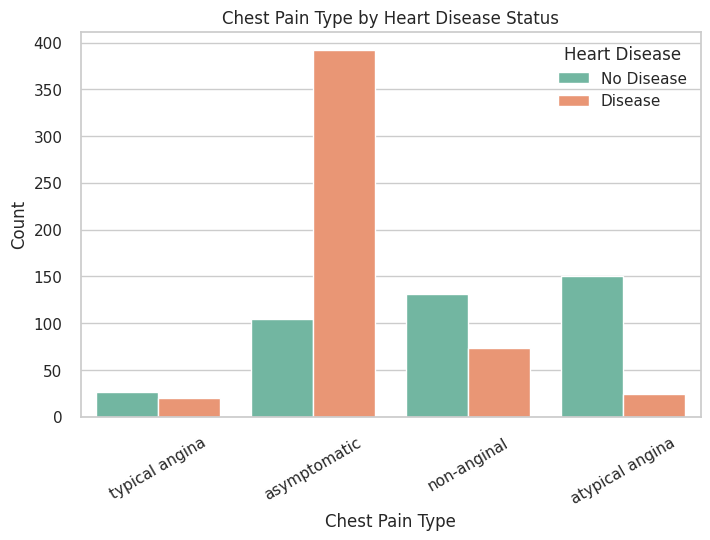

In [45]:
# 9. EDA: Chest Pain Type by Heart Disease Status

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="cp",
    hue="HeartDisease",
    palette="Set2"
)

plt.title("Chest Pain Type by Heart Disease Status")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
plt.show()

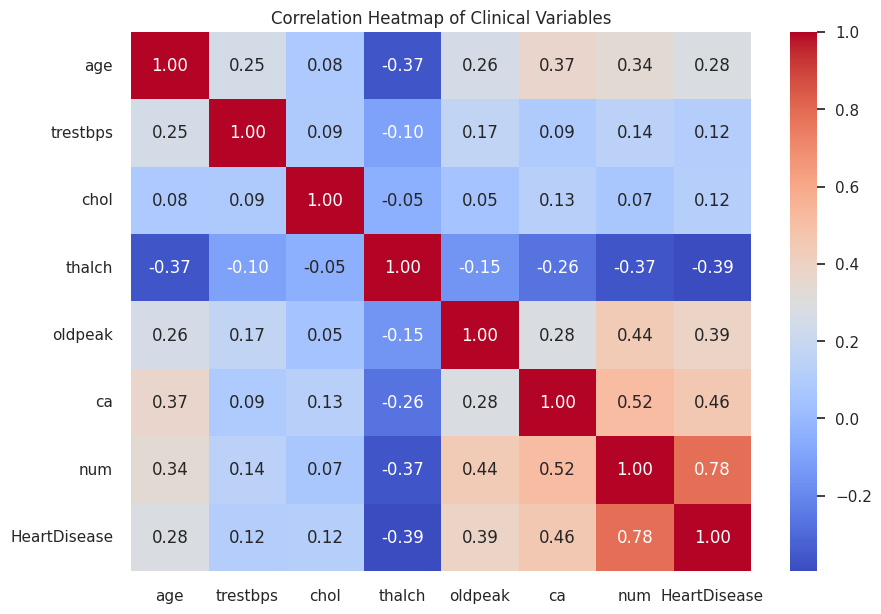

In [46]:
# 10. Multivariate EDA: Correlation Heatmap

numeric_cols_for_corr = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca",
    "num",
    "HeartDisease"
]

numeric_cols_for_corr = [col for col in numeric_cols_for_corr if col in df_clean.columns]

corr = df_clean[numeric_cols_for_corr].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Clinical Variables")
plt.show()

In [47]:
# 11. Prepare Features and Target

# Remove ID, dataset source column, original target, and binary target from features
drop_cols = ["id", "dataset", "num", "HeartDisease"]

X = df_clean.drop(columns=drop_cols)
y = df_clean["HeartDisease"]

# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [48]:
# 12. Preprocessing Pipeline

# Numerical preprocessing:
# Missing values are filled using median.
# Scaling is applied for Logistic Regression and KMeans.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# Missing values are filled using most frequent value.
# One-hot encoding converts categories into numerical form.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [49]:
# 13. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts())

print("\nTesting target distribution:")
display(y_test.value_counts())

Training set size: (736, 13)
Testing set size: (184, 13)

Training target distribution:


,count
HeartDisease,
1,407
0,329



Testing target distribution:


,count
HeartDisease,
1,102
0,82


In [50]:
# 14. Classification Model 1: Logistic Regression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr), 4))
print("F1-score:", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Results ===
Accuracy: 0.8098
Precision: 0.819
Recall: 0.8431
F1-score: 0.8309
ROC-AUC: 0.8895

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78        82
           1       0.82      0.84      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184



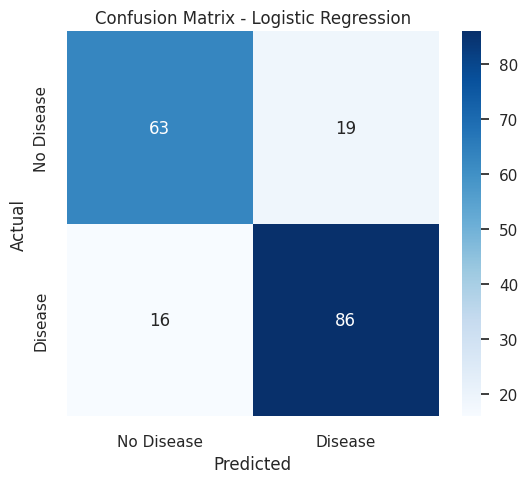

In [51]:
# 15. Confusion Matrix: Logistic Regression

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
# 16. Classification Model 2: Random Forest

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1-score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy: 0.7935
Precision: 0.8019
Recall: 0.8333
F1-score: 0.8173
ROC-AUC: 0.9052

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        82
           1       0.80      0.83      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184



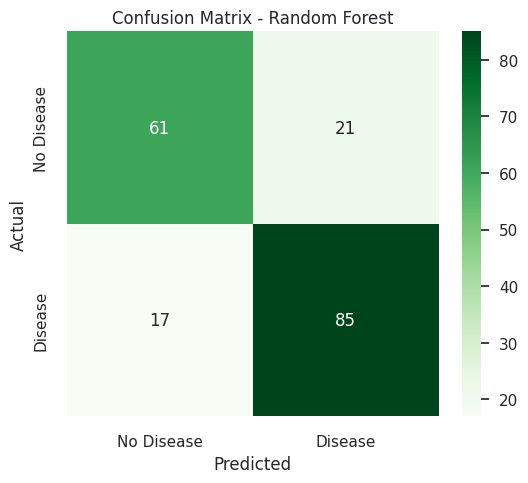

In [53]:
# 17. Confusion Matrix: Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8098,0.8190,0.8431,0.8309,0.8895
1,Random Forest,0.7935,0.8019,0.8333,0.8173,0.9052


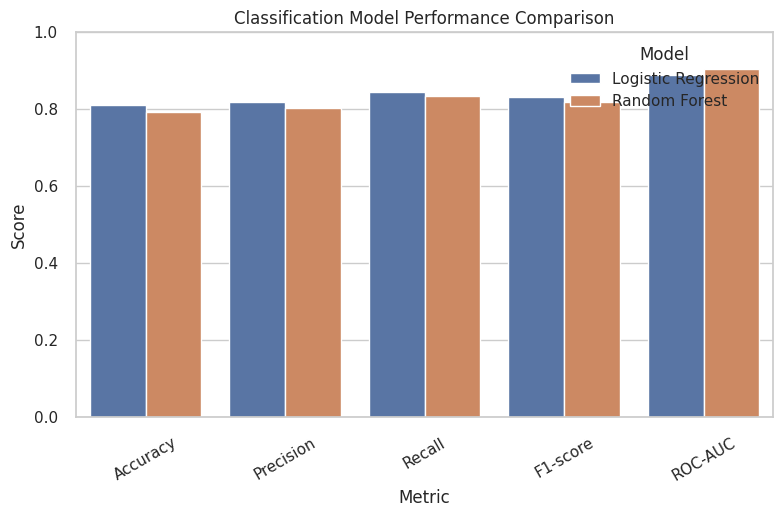

In [54]:
# 18. Compare Classification Models

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison = comparison.round(4)

print("Model Comparison:")
display(comparison)

comparison_melted = comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Classification Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

<Figure size 700x500 with 0 Axes>

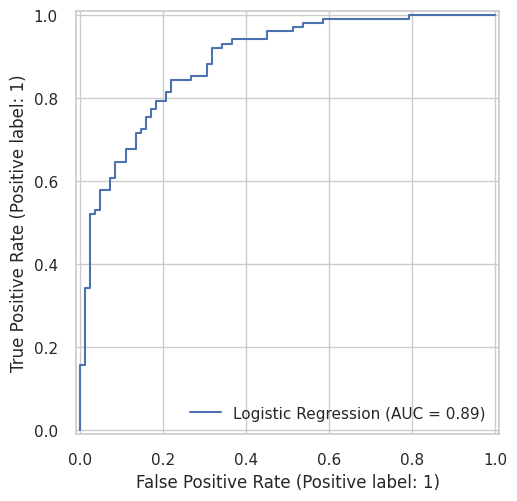

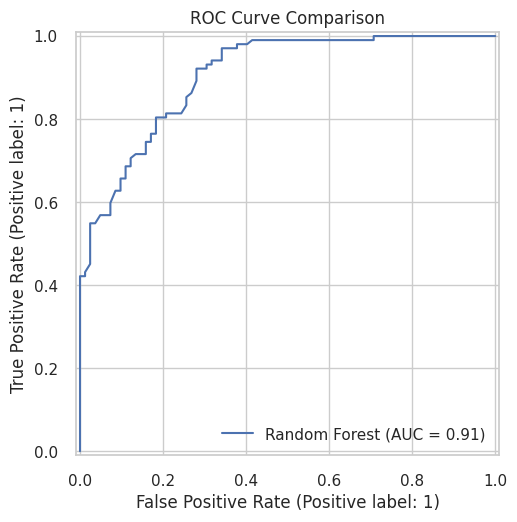

In [55]:
# 19. ROC Curve Comparison

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()

Top 15 Important Features:


,Feature,Importance
3,num__thalch,0.114592
0,num__age,0.114408
2,num__chol,0.107484
4,num__oldpeak,0.100490
8,cat__cp_asymptomatic,0.099181
1,num__trestbps,0.073371
18,cat__exang_True,0.060789
17,cat__exang_False,0.045739
9,cat__cp_atypical angina,0.040832
7,cat__sex_Male,0.026787


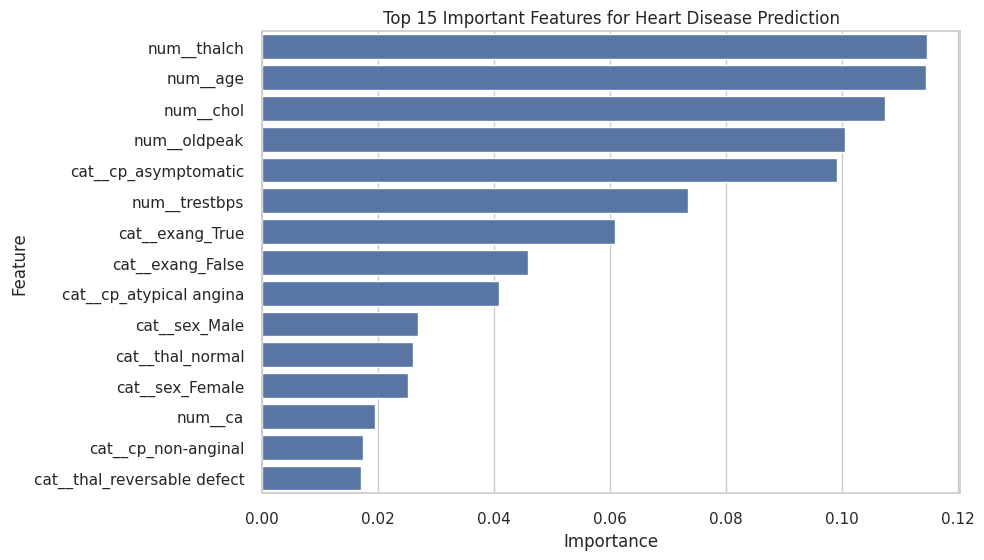

In [56]:
# 20. Feature Importance from Random Forest

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

print("Top 15 Important Features:")
display(feature_importance_df.head(15))

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features for Heart Disease Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [57]:
# 21. Clustering Preparation

# Clustering uses the same patient health features without target labels.
X_cluster = X.copy()

# Apply preprocessing to convert all features into numerical scaled format.
X_cluster_processed = preprocessor.fit_transform(X_cluster)

print("Processed clustering data shape:", X_cluster_processed.shape)

Processed clustering data shape: (920, 25)


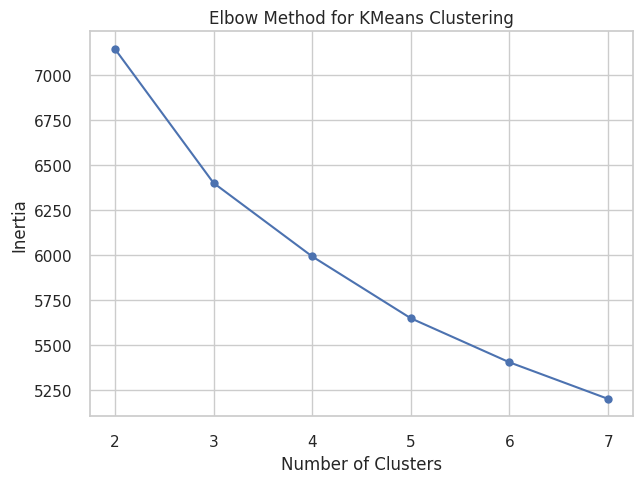

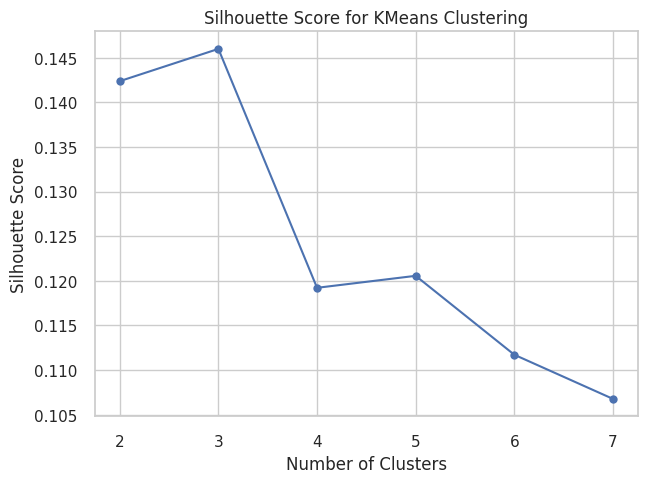

Clustering Evaluation:


,Number of Clusters,Inertia,Silhouette Score
0,2,7144.176807,0.142375
1,3,6399.120770,0.145991
2,4,5990.906688,0.119212
3,5,5647.135322,0.120554
4,6,5402.451197,0.111708
5,7,5199.200131,0.106760


In [58]:
# 22. Find Suitable Number of Clusters

inertia_values = []
silhouette_values = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_cluster_processed)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_cluster_processed, cluster_labels))

# Elbow plot
plt.figure(figsize=(7, 5))
plt.plot(list(K_range), inertia_values, marker="o")
plt.title("Elbow Method for KMeans Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Silhouette score plot
plt.figure(figsize=(7, 5))
plt.plot(list(K_range), silhouette_values, marker="o")
plt.title("Silhouette Score for KMeans Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

silhouette_df = pd.DataFrame({
    "Number of Clusters": list(K_range),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_values
})

print("Clustering Evaluation:")
display(silhouette_df)

In [59]:
# 23. Apply KMeans Clustering

# Choose 3 clusters to represent different patient health profiles.
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df_clean["Cluster"] = kmeans.fit_predict(X_cluster_processed)

print("Cluster distribution:")
display(df_clean["Cluster"].value_counts().sort_index())

Cluster distribution:


,count
Cluster,
0,95
1,413
2,412


In [60]:
# 24. Cluster Profiling

cluster_profile = df_clean.groupby("Cluster").agg({
    "age": "mean",
    "trestbps": "mean",
    "chol": "mean",
    "thalch": "mean",
    "oldpeak": "mean",
    "HeartDisease": "mean"
}).reset_index()

cluster_profile["HeartDisease_Rate_%"] = cluster_profile["HeartDisease"] * 100

cluster_profile = cluster_profile.round(2)

print("Cluster Profile:")
display(cluster_profile)

Cluster Profile:


,Cluster,age,trestbps,chol,thalch,oldpeak,HeartDisease,HeartDisease_Rate_%
0,0,60.21,134.46,258.14,141.24,1.59,0.80,80.00
1,1,58.27,138.54,252.66,119.11,1.25,0.77,77.48
2,2,47.19,125.68,239.15,154.61,0.35,0.27,27.43


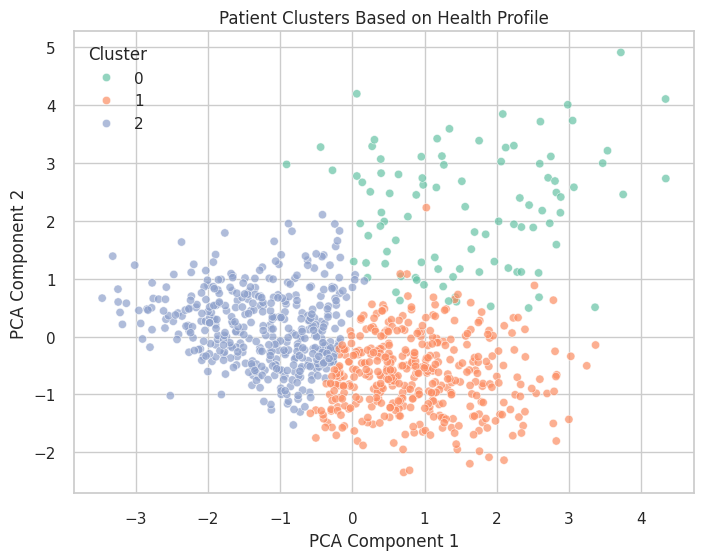

In [61]:
# 25. Visualize Patient Clusters using PCA

pca = PCA(n_components=2, random_state=42)

# Convert sparse matrix to dense if needed
if hasattr(X_cluster_processed, "toarray"):
    X_cluster_dense = X_cluster_processed.toarray()
else:
    X_cluster_dense = X_cluster_processed

X_pca = pca.fit_transform(X_cluster_dense)

df_clean["PCA1"] = X_pca[:, 0]
df_clean["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    alpha=0.7
)

plt.title("Patient Clusters Based on Health Profile")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

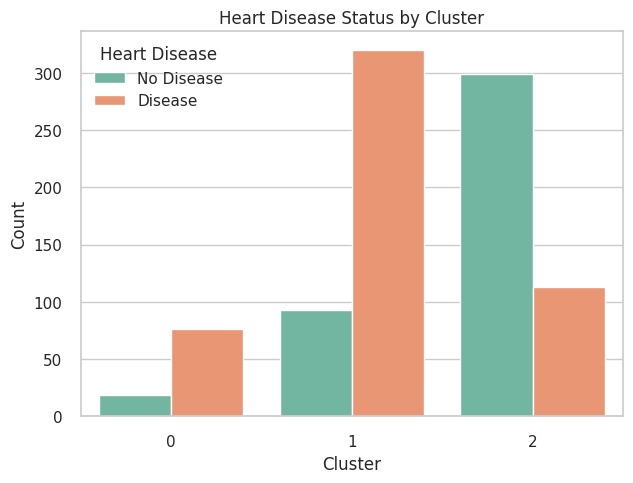

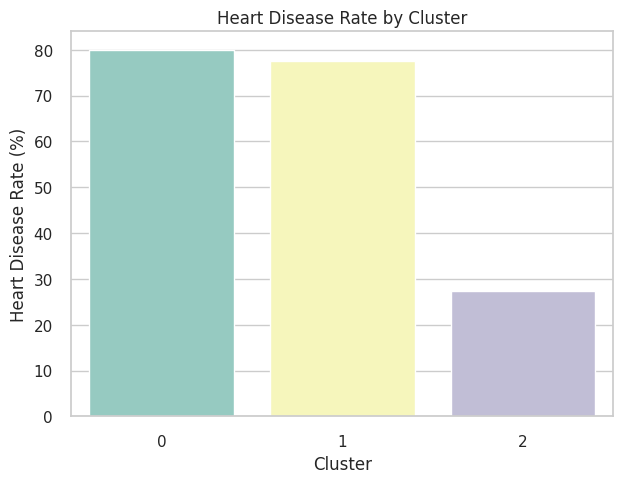

In [62]:
# 26. Cluster vs Heart Disease Status

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Cluster",
    hue="HeartDisease",
    palette="Set2"
)

plt.title("Heart Disease Status by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
plt.show()

cluster_risk = df_clean.groupby("Cluster")["HeartDisease"].mean().reset_index()
cluster_risk["HeartDisease_Rate_%"] = cluster_risk["HeartDisease"] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=cluster_risk,
    x="Cluster",
    y="HeartDisease_Rate_%",
    hue="Cluster",
    palette="Set3",
    legend=False
)

plt.title("Heart Disease Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Heart Disease Rate (%)")
plt.show()

In [63]:
# 27. Final Summary

best_model = comparison.sort_values(by="F1-score", ascending=False).iloc[0]

summary = {
    "Total Records": len(df_clean),
    "Total Variables After Processing": df_clean.shape[1],
    "Heart Disease Cases": int(df_clean["HeartDisease"].sum()),
    "No Heart Disease Cases": int((df_clean["HeartDisease"] == 0).sum()),
    "Best Classification Model": best_model["Model"],
    "Best F1-score": best_model["F1-score"],
    "Number of Clusters": k
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

print("Final Summary:")
display(summary_df)

Final Summary:


,Metric,Value
0,Total Records,920
1,Total Variables After Processing,20
2,Heart Disease Cases,509
3,No Heart Disease Cases,411
4,Best Classification Model,Logistic Regression
5,Best F1-score,0.8309
6,Number of Clusters,3
